In [22]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
from nltk.tokenize import sent_tokenize, word_tokenize

sample_text = """
The new retail inventory chatbot successfully classifies user intent.
It interacts with backend APIs for fast inventory management, billing, and real-time analysis.
Customers are responding well to the automated system!
"""

In [7]:
sentences = sent_tokenize(sample_text)
print("--- Sentence Tokenization ---")
for i, sentence in enumerate(sentences):
    print(f"Sentence {i+1}: {sentence}")

--- Sentence Tokenization ---
Sentence 1: 
The new retail inventory chatbot successfully classifies user intent.
Sentence 2: It interacts with backend APIs for fast inventory management, billing, and real-time analysis.
Sentence 3: Customers are responding well to the automated system!


In [13]:
# 2. Word Tokenization: Breaks the text into individual words and punctuation
words = word_tokenize(sample_text)
print("\n--- Word Tokenization ---")
print(words[:15])
print(words[15:31])
print(words[31:])


--- Word Tokenization ---
['The', 'new', 'retail', 'inventory', 'chatbot', 'successfully', 'classifies', 'user', 'intent', '.', 'It', 'interacts', 'with', 'backend', 'APIs']
['for', 'fast', 'inventory', 'management', ',', 'billing', ',', 'and', 'real-time', 'analysis', '.', 'Customers', 'are', 'responding', 'well', 'to']
['the', 'automated', 'system', '!']


In [14]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Initialize the lemmatizer and get English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [20]:
cleaned_words = []

for word in words:
    word_lower = word.lower()

    # Filter out punctuation and stopwords
    if word_lower not in string.punctuation and word_lower not in stop_words:
        # Lemmatize the word (pos='v' treats the word as a verb for better root extraction)
        root_word = lemmatizer.lemmatize(word_lower, pos='v')
        cleaned_words.append(root_word)

print("--- Cleaned and Lemmatized Text ---")
print(cleaned_words[:15])
print(cleaned_words[15:])

--- Cleaned and Lemmatized Text ---
['new', 'retail', 'inventory', 'chatbot', 'successfully', 'classify', 'user', 'intent', 'interact', 'backend', 'apis', 'fast', 'inventory', 'management', 'bill']
['real-time', 'analysis', 'customers', 'respond', 'well', 'automate', 'system']


In [27]:
# Perform POS Tagging on the original word tokens
pos_tags = nltk.pos_tag(words)

print("--- Part of Speech Tagging ---")
# Print the first 10 tagged words
for word, tag in pos_tags[:]:
    print(f"{word:15} -> {tag}")

--- Part of Speech Tagging ---
The             -> DT
new             -> JJ
retail          -> JJ
inventory       -> NN
chatbot         -> NN
successfully    -> RB
classifies      -> VBZ
user            -> JJ
intent          -> NN
.               -> .
It              -> PRP
interacts       -> VBZ
with            -> IN
backend         -> NN
APIs            -> NNP
for             -> IN
fast            -> RB
inventory       -> JJ
management      -> NN
,               -> ,
billing         -> NN
,               -> ,
and             -> CC
real-time       -> JJ
analysis        -> NN
.               -> .
Customers       -> NNS
are             -> VBP
responding      -> VBG
well            -> RB
to              -> TO
the             -> DT
automated       -> JJ
system          -> NN
!               -> .


--- Most Common Words ---
[('inventory', 2), ('new', 1), ('retail', 1), ('chatbot', 1), ('successfully', 1), ('classify', 1), ('user', 1), ('intent', 1), ('interact', 1), ('backend', 1)]


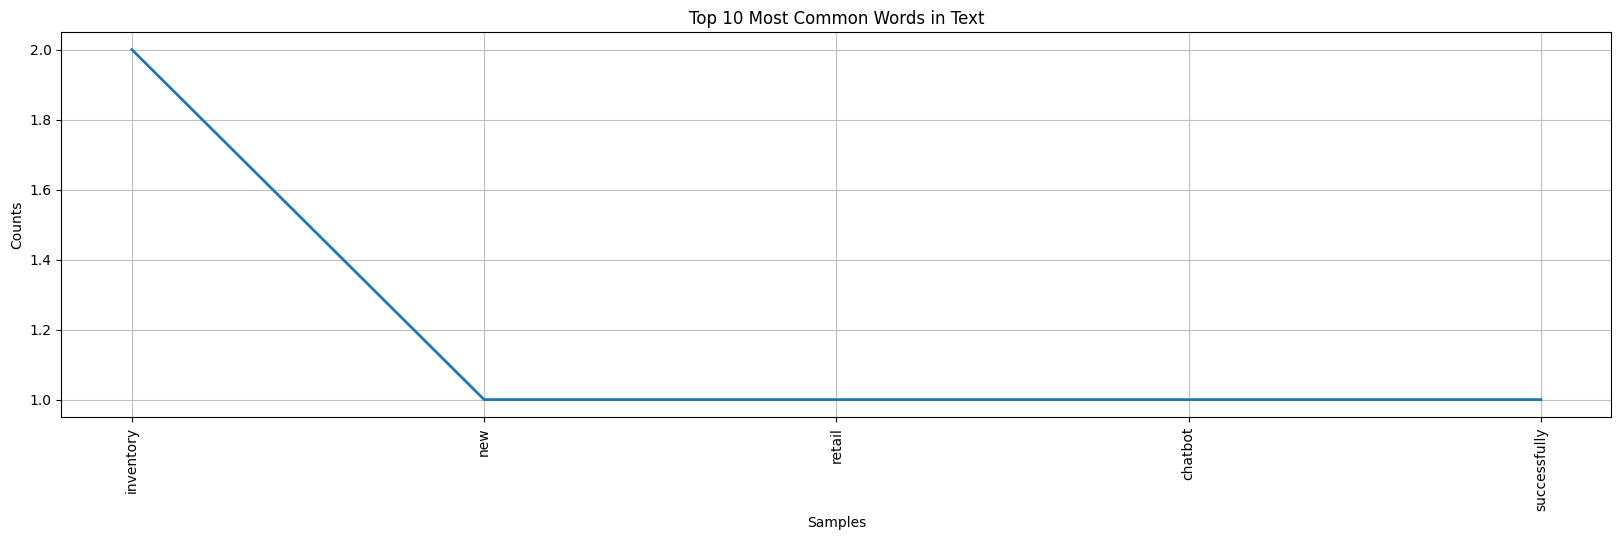

In [35]:
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

# Calculate frequency distribution on our cleaned words
freq_dist = FreqDist(cleaned_words)

print("--- Most Common Words ---")
print(freq_dist.most_common(10))

# Plot the top 10 most common words
plt.figure(figsize=(20, 5))
freq_dist.plot(5, title="Top 10 Most Common Words in Text")
plt.show()